[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/raulpg14/Quantum-Internet-Network-Simulator/blob/master/notebooks/01_degree_distribution.ipynb)

# Degree distribution analysis — OFBQI and SBQI
Notebook for analysing and comparing degree distributions of OFBQI and SBQI quantum network structures.
Compatible with local Jupyter and Google Colab.

In [1]:
import sys
try:
    import qcn
except ImportError:
    import subprocess
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--quiet',
        'git+https://github.com/raulpg14/Quantum-Internet-Network-Simulator.git'
    ])
    import qcn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from qcn.engine.simulation import run_simulation
from qcn.engine.config import (
    NETWORK_TYPE_OFBQI, NETWORK_TYPE_SBQI,
    SIM_MODE_DISTRIBUTION, STYLE_MAP,
    DEFAULT_RADIUS_DISTRIBUTION,
)
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [3]:
# --- Simulation parameters ---
NODES = 1000
RADIUS = DEFAULT_RADIUS_DISTRIBUTION
MC_REPS = 10
SEED = 42
# -----------------------------

In [4]:
results = {}
for net_type in [NETWORK_TYPE_OFBQI, NETWORK_TYPE_SBQI]:
    res = run_simulation({
        'nodes': NODES,
        'radius': RADIUS,
        'type': net_type,
        'mc_iter': MC_REPS,
        'sim_mode': SIM_MODE_DISTRIBUTION,
        'seed': SEED,
    })
    if res.get('success'):
        results[net_type] = res
        print(f"{net_type}: OK — density={res['density_val']:.6f}")
    else:
        print(f"{net_type}: ERROR — {res.get('error')}")

OFBQI: OK — density=0.000200
SBQI: OK — density=0.000200


In [ ]:
import time
from qcn.engine.results_store import save_run, get_runs

# Save results to the database
for net_type, res in results.items():
    run_id = save_run(res, duration_s=0.0)
    print(f"{net_type}: saved as run_id={run_id}")

# Show all runs in the database
runs = get_runs()
print(f"\nTotal runs in database: {len(runs)}")

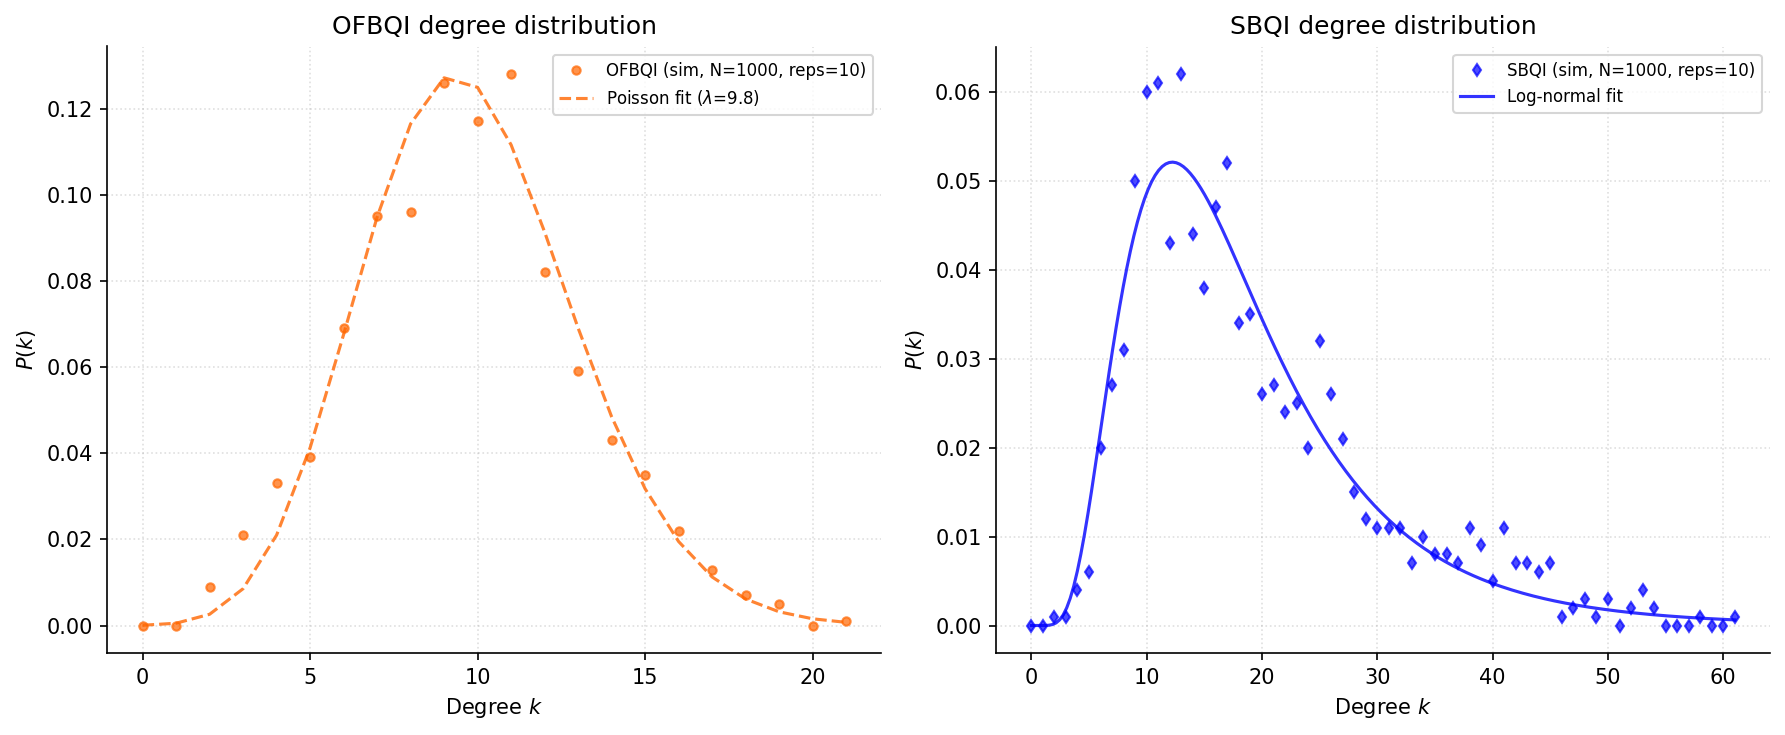

Figure saved to degree_distribution.pdf


In [7]:
from scipy.optimize import curve_fit
from scipy.stats import poisson, lognorm

def fit_poisson(k, lamb):
    return poisson.pmf(k, lamb)

def fit_lognormal(x, s, scale):
    return lognorm.pdf(x, s, 0, scale)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, net_type in zip(axes, [NETWORK_TYPE_OFBQI, NETWORK_TYPE_SBQI]):
    if net_type not in results:
        continue
    res = results[net_type]
    style = STYLE_MAP[net_type]
    x_values = res['dist_x']
    y_values = res['dist_y']

    # Plot simulation points
    ax.plot(x_values, y_values,
            color=style['color'], marker=style['marker'],
            linestyle='', markersize=4, alpha=0.7,
            label=f"{style['label']} (sim, N={NODES}, reps={MC_REPS})")

    # Plot fit curve
    if len(x_values) > 2:
        try:
            if net_type == NETWORK_TYPE_OFBQI:
                mean_k = np.average(x_values, weights=y_values)
                popt, _ = curve_fit(fit_poisson, x_values, y_values, p0=[mean_k])
                x_fit = np.arange(min(x_values), max(x_values) + 1)
                ax.plot(x_fit, fit_poisson(x_fit, *popt),
                        color=style['color'], linestyle='--', alpha=0.8,
                        label=rf"Poisson fit ($\lambda$={popt[0]:.1f})")

            elif net_type == NETWORK_TYPE_SBQI:
                x_fit = np.linspace(min(x_values), max(x_values), 200)
                p0 = [0.5, np.mean(x_values)]
                popt, _ = curve_fit(fit_lognormal, x_values, y_values,
                                    p0=p0, maxfev=5000)
                ax.plot(x_fit, fit_lognormal(x_fit, *popt),
                        color=style['color'], linestyle='-', linewidth=1.5,
                        alpha=0.8, label="Log-normal fit")
        except Exception as e:
            print(f"Fit warning ({net_type}): {e}")

    ax.set_xlabel('Degree $k$')
    ax.set_ylabel('$P(k)$')
    ax.set_title(f'{net_type} degree distribution')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('degree_distribution.pdf', bbox_inches='tight')
plt.show()
print('Figure saved to degree_distribution.pdf')

## Results summary

In [8]:
print(f"{'Network':<10} {'Nodes':>8} {'Radius':>10} {'Density':>14} {'Seed':>6}")
print('-' * 54)
for net_type, res in results.items():
    print(f"{net_type:<10} {res['final_n']:>8} {res['final_radius']:>10.1f} {res['density_val']:>14.2e} {res.get('seed','N/A'):>6}")

Network       Nodes     Radius        Density   Seed
------------------------------------------------------
OFBQI          1000     1261.0       2.00e-04     42
SBQI           1000     1261.0       2.00e-04     42
